# Why censoring Kaplan–Meier needs event-before-censoring tie handling

Inverse probability of censoring weighting (IPCW) depends on an estimate of censoring survival, $\widehat G(t)$. If an original event and a censoring share a recorded time (aka, tied), simply flipping the event indicators and fitting ordinary Kaplan–Meier (KM) uses the wrong risk set **for the original-events-first convention**.

This notebook compares the old and corrected estimates on four training subjects, explains the denominator adjustment, and shows its effect on Brier scores, integrated Brier score (IBS), and Uno concordance.

**Version history:** SurvivalEVAL used the old flipped-indicator implementation **<= 0.8.5**. **Starting with version 0.8.6**, SurvivalEVAL corrects it with `KaplanMeier(..., reverse=True)` and uses that mode throughout the censoring-KM IPCW paths. 

Run this notebook with the corrected SurvivalEVAL (ie, >= 0.8.6) source installed, for example with `python -m pip install -e .` from the repository root. It uses the package's existing NumPy, pandas, SciPy, and Matplotlib dependencies; scikit-survival is not required.

In [1]:
import inspect

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import trapezoid

from SurvivalEVAL import (
    SurvivalEvaluator,
    __version__,
    brier_multiple_points,
    concordance,
)
from SurvivalEVAL.NonparametricEstimator.SingleEvent import KaplanMeier

if "reverse" not in inspect.signature(KaplanMeier).parameters:
    raise RuntimeError(
        "Install SurvivalEVAL source containing the reverse-KM correction. "
        "Released version 0.8.5 does not include it."
    )

print("Reverse-KM correction is available.")


Reverse-KM correction is available.


## A Simple Example with Tied Events and Censorings

All four subjects are under observation immediately before day 10. Subject A has an event at day 10, subject B is censored at day 10, and subjects C and D have later events. Original event indicators are `True` for events and `False` for censoring.

In [2]:
train_times = np.array([10.0, 10.0, 15.0, 20.0])
train_events = np.array([True, False, True, True])

pd.DataFrame(
    {
        "Subject": ["A", "B", "C", "D"],
        "Observed time": train_times,
        "Outcome": np.where(train_events, "Event", "Censored"),
    }
)


,Subject,Observed time,Outcome
0,A,10.0,Event
1,B,10.0,Censored
2,C,15.0,Event
3,D,20.0,Event


The old censoring estimate treats censorings as events in an ordinary KM fit. The corrected fit takes the **original** indicators and applies the event-first risk-set adjustment internally.

In [3]:
# Reproduce the old censoring estimate without installing an older release.
old_g = KaplanMeier(train_times, ~train_events)

# Corrected censoring estimate: do not invert the indicators.
new_g = KaplanMeier(train_times, train_events, reverse=True)

assert np.isclose(old_g.predict(10.0), 3 / 4)
assert np.isclose(new_g.predict(10.0), 2 / 3)

query_times = np.array([0.0, 9.0, 10.0, 12.0, 15.0, 20.0])
pd.DataFrame(
    {
        "Time": query_times,
        "Old censoring survival": old_g.predict(query_times),
        "Corrected censoring survival": new_g.predict(query_times),
    }
)


,Time,Old censoring survival,Corrected censoring survival
0,0.0,1.00,1.000000
1,9.0,1.00,1.000000
2,10.0,0.75,0.666667
3,12.0,0.75,0.666667
4,15.0,0.75,0.666667
5,20.0,0.75,0.666667


## 2. Why the denominator changes

At a tied time $u$, let $n_u$ be the number at risk immediately before the time, $d_u$ the number of original events, and $c_u$ the number of original censorings.

With **original events before censorings**, the $d_u$ event subjects leave first. The censoring update therefore acts on $n_u-d_u$ subjects:

$$
\widehat G_{\mathrm{old}}(t)
=\prod_{u\leq t}\left(1-\frac{c_u}{n_u}\right),
\qquad
\widehat G_{\mathrm{new}}(t)
=\prod_{u\leq t}\left(1-\frac{c_u}{n_u-d_u}\right).
$$

At day 10, $n_u=4$, $d_u=1$, and $c_u=1$. The old update is $1-1/4=3/4$. After subject A's event, three subjects remain for the censoring update, so the corrected update is $1-1/3=2/3$.

There is also a useful bookkeeping check. Ordinary event KM includes tied censorings in the event risk set, giving the event-survival factor $1-d_u/n_u$. Combining it with the corrected censoring factor gives

$$
\left(1-\frac{d_u}{n_u}\right)
\left(1-\frac{c_u}{n_u-d_u}\right)
=1-\frac{d_u+c_u}{n_u}.
$$

That is exactly the fraction still under observation after both departures. At day 10, two of four remain: $(3/4)(2/3)=1/2$. Using the old censoring factor gives $(3/4)(3/4)=9/16$, which does not match the two departures under this sequential convention.

The correction makes censoring KM consistent with the event-first convention used by [scikit-survival's reverse KM](https://github.com/sebp/scikit-survival/blob/v0.28.0/sksurv/nonparametric.py#L257-L262) and [prodlim's reverse update](https://github.com/tagteam/prodlim/blob/master/src/prodlim.c#L109-L114). This is a choice of tie convention, not a claim that rounded times reveal the actual within-day order. Interpreting a marginal censoring estimate for IPCW still requires the usual independent-censoring assumptions.

In [4]:
event_survival_at_10 = KaplanMeier(train_times, train_events).predict(10.0)
fraction_still_observed = np.mean(train_times > 10.0)

assert np.isclose(event_survival_at_10 * new_g.predict(10.0), fraction_still_observed)

pd.DataFrame(
    {
        "Censoring estimator": ["Old", "Corrected"],
        "Event survival at 10": [event_survival_at_10] * 2,
        "Censoring survival at 10": [old_g.predict(10.0), new_g.predict(10.0)],
        "Product": [
            event_survival_at_10 * old_g.predict(10.0),
            event_survival_at_10 * new_g.predict(10.0),
        ],
        "Fraction still observed": [fraction_still_observed] * 2,
    }
)


,Censoring estimator,Event survival at 10,Censoring survival at 10,Product,Fraction still observed
0,Old,0.75,0.750000,0.5625,0.5
1,Corrected,0.75,0.666667,0.5000,0.5


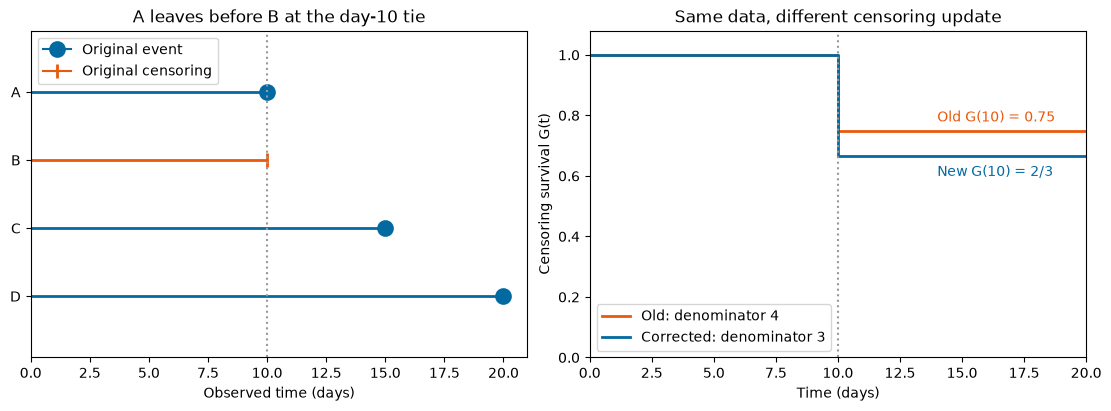

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

for i, (time, is_event) in enumerate(zip(train_times, train_events)):
    color = "#0369a1" if is_event else "#ea580c"
    axes[0].hlines(3 - i, 0, time, color=color, linewidth=2)
    axes[0].plot(
        time,
        3 - i,
        marker="o" if is_event else "|",
        color=color,
        markersize=10,
        markeredgewidth=2,
        label=(
            "Original event"
            if i == 0
            else ("Original censoring" if not is_event else None)
        ),
    )
axes[0].axvline(10, color="0.6", linestyle=":")
axes[0].set(yticks=[3, 2, 1, 0], yticklabels=["A", "B", "C", "D"], xlim=(0, 21))
axes[0].set_xlabel("Observed time (days)")
axes[0].set_title("A leaves before B at the day-10 tie")
axes[0].legend(loc="upper left")
axes[0].margins(y=0.3)

for model, label, color in [
    (old_g, "Old: denominator 4", "#ea580c"),
    (new_g, "Corrected: denominator 3", "#0369a1"),
]:
    axes[1].step(
        model.survival_times,
        model.survival_probabilities,
        where="post",
        label=label,
        color=color,
        linewidth=2,
    )
axes[1].axvline(10, color="0.6", linestyle=":")
axes[1].text(14, 0.78, "Old G(10) = 0.75", color="#ea580c")
axes[1].text(14, 0.60, "New G(10) = 2/3", color="#0369a1")
axes[1].set(
    xlim=(0, 20), ylim=(0, 1.08), xlabel="Time (days)", ylabel="Censoring survival G(t)"
)
axes[1].set_title("Same data, different censoring update")
axes[1].legend(loc="lower left")
plt.show()


## 3. The effect on IPCW weights and metrics

Brier scores use weights involving $1/\widehat G(t)$ or $1/\widehat G(Y_i)$, where $Y_i$ is a subject's observed time. Uno concordance weights an event anchor by $1/\widehat G(Y_i)^2$. After the day-10 censoring, the old estimate gives smaller inverse weights:

In [6]:
g_at_12 = np.array([old_g.predict(12.0), new_g.predict(12.0)])
pd.DataFrame(
    {"G(12)": g_at_12, "1 / G(12)": 1 / g_at_12, "1 / G(12)^2": 1 / g_at_12**2},
    index=["Old", "Corrected"],
)


,G(12),1 / G(12),1 / G(12)^2
Old,0.750000,1.333333,1.777778
Corrected,0.666667,1.500000,2.250000


Use held-out times `[5, 12, 15, 18]`, event indicators `[True, True, False, True]`, and evaluation times `[6, 13, 16]`. Every subject receives survival probabilities `[0.8, 0.6, 0.4]` on that grid.

To reproduce old results, the next cell evaluates the Brier formula using `old_g`, then compares it with the corrected library API. For this example all queried censoring probabilities are positive, the queries stay within the training follow-up range, and none of the evaluation times equals a recorded subject time. Thus only the fitted censoring estimate changes.

In [7]:
test_times = np.array([5.0, 12.0, 15.0, 18.0])
test_events = np.array([True, True, False, True])
grid = np.array([6.0, 13.0, 16.0])
predictions = np.tile([0.8, 0.6, 0.4], (4, 1))

# The two Brier components use G at the event time and at the target time.
observed_event = (test_times[:, None] <= grid) & test_events[:, None]
event_free = (test_times[:, None] > grid) | (
    (test_times[:, None] == grid) & ~test_events[:, None]
)
old_brier = np.mean(
    predictions**2 * observed_event / old_g.predict(test_times)[:, None]
    + (1 - predictions) ** 2 * event_free / old_g.predict(grid),
    axis=0,
)
new_brier = brier_multiple_points(
    predictions, test_times, test_events, train_times, train_events, grid
)

old_ibs = trapezoid(old_brier, grid) / np.ptp(grid)
evaluator = SurvivalEvaluator(
    pred_survs=np.column_stack((np.ones(4), predictions)),
    time_coordinates=np.r_[0.0, grid],
    event_times=test_times,
    event_indicators=test_events,
    train_event_times=train_times,
    train_event_indicators=train_events,
)
new_ibs = evaluator.integrated_brier_score(target_times=grid)

np.testing.assert_allclose(old_brier, [0.19, 0.3166666666666667, 0.2133333333333333])
np.testing.assert_allclose(new_brier, [0.19, 0.345, 0.235])
assert np.isclose(new_ibs, 0.27425)


For Uno concordance, use risk scores `[2, 4, 3, 1]` and `tau=16`. Larger risk means a shorter predicted survival time, so SurvivalEVAL receives **negative risk** as `predicted_times`.

There are two contributing event anchors. At time 5, one of three pairs is concordant. At time 12, both pairs are concordant. The event at time 18 is excluded by `tau`. These fixed pair counts let us reproduce the old Uno result directly, without duplicating the library's pair-counting algorithm.

In [8]:
risks = np.array([2.0, 4.0, 3.0, 1.0])
anchor_times = np.array([5.0, 12.0])
old_anchor_weights = 1 / old_g.predict(anchor_times) ** 2
old_uno = np.dot(old_anchor_weights, [1, 2]) / np.dot(old_anchor_weights, [3, 2])
new_uno = concordance(
    predicted_times=-risks,
    event_times=test_times,
    event_indicators=test_events,
    train_event_times=train_times,
    train_event_indicators=train_events,
    method="Uno",
    ties="Risk",
    tau=16.0,
)[0]

assert np.isclose(old_uno, 41 / 59)
assert np.isclose(new_uno, 11 / 15)

comparison = pd.DataFrame(
    {
        "Old implementation": [*old_brier, old_ibs, old_uno],
        "Corrected implementation": [*new_brier, new_ibs, new_uno],
    },
    index=[
        "Brier at 6",
        "Brier at 13",
        "Brier at 16",
        "IBS over [6, 16]",
        "Uno, tau=16",
    ],
)
comparison.round(10)


,Old implementation,Corrected implementation
Brier at 6,0.190000,0.190000
Brier at 13,0.316667,0.345000
Brier at 16,0.213333,0.235000
"IBS over [6, 16]",0.256833,0.274250
"Uno, tau=16",0.694915,0.733333


Brier at time 6 is unchanged because no censoring has occurred yet. Later Brier scores, IBS, and Uno change because their weights use the corrected estimate after day 10. The predictions and outcomes are identical in both calculations; this is a correction to evaluation, not an improvement to the prediction model. A corrected Uno value is not guaranteed to increase for other rankings.

The same censoring estimator is now used by single-time and multi-time Brier scores, IBS, Uno/IPCW concordance, time-dependent IPCW concordance, and IPCW-D MAE/MSE/RMSE.

## 4. What changes, and what stays separate

If no time contains both original events and censorings, the censoring updates agree: at a censoring time $d_u=0$, and at an event-only time $c_u=0$. In an all-observed training set, censoring survival remains one. A terminal event-only group can have $n_u-d_u=0$; because there are no censorings, its update factor is one rather than an undefined $0/0$.

The denominator correction is separate from choosing $G(t)$ or the left limit $G(t-)$. SurvivalEVAL continues to use right-continuous $G(t)$: a query exactly at day 10 includes that day's censoring update. Its existing tail extrapolation and metric-specific handling of zero censoring survival also remain separate from this change.

In [9]:
# Without mixed ties, both estimates agree.
no_tie_times = np.array([10.0, 11.0, 15.0, 20.0])
old_no_ties = KaplanMeier(no_tie_times, ~train_events)
new_no_ties = KaplanMeier(no_tie_times, train_events, reverse=True)
np.testing.assert_allclose(
    old_no_ties.survival_probabilities, new_no_ties.survival_probabilities
)

# No censorings: even the final zero risk set must leave G unchanged.
with np.errstate(divide="raise", invalid="raise"):
    all_observed = KaplanMeier(train_times, np.ones(4, dtype=bool), reverse=True)
np.testing.assert_allclose(all_observed.survival_probabilities, 1.0)

# This is G(t), not G(t-): check immediately before and exactly at the tie.
assert np.isclose(new_g.predict(np.nextafter(10.0, 0.0)), 1.0)
assert np.isclose(new_g.predict(10.0), 2 / 3)
print(
    "Verified: agreement without mixed ties, all-observed training, and exact-time behavior."
)


Verified: agreement without mixed ties, all-observed training, and exact-time behavior.
